# 3D pipeline: zero-shot FM rotation search
This notebook evaluates a 2D-trained rotation FM on the Ganis-Kievit 3D stimuli
(preprocessed in `data/train_pairs.npy` and `data/test_balanced.npy`).

We treat the FM as a rotation operator and perform a deterministic angle search.
No retraining. Metrics are computed on the balanced test set.


In [17]:
%cd /Users/masha/Documents/visual-reasoning

import os
import math
import random
from typing import List, Tuple, Dict, Any

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import timm

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

from sklearn.metrics import roc_auc_score, accuracy_score
import matplotlib.pyplot as plt


/Users/masha/Documents/visual-reasoning


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_PATH = "models/rotator_l1_500e_10k.pth"
FM_STEPS = 10
ANGLE_STEP = 10  # set to 5 for denser search
ANGLES = np.arange(0, 360, ANGLE_STEP, dtype=np.float32)

MAX_TEST = None   # set to int for quick debug
MAX_TRAIN = None  # set to int for quick debug


Device: cpu


In [19]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.net(x)

class FastRotator(nn.Module):
    def __init__(self, backbone_dim=384, flow_dim=64):
        super().__init__()
        self.time_mlp = nn.Sequential(nn.Linear(1, flow_dim * 4), nn.GELU(), nn.Linear(flow_dim * 4, flow_dim * 4))
        self.angle_mlp = nn.Sequential(nn.Linear(1, flow_dim * 4), nn.GELU(), nn.Linear(flow_dim * 4, flow_dim * 4))
        self.cond_proj = nn.Linear(backbone_dim, flow_dim * 4)

        self.inc = DoubleConv(1, flow_dim)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim, flow_dim * 2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim * 2, flow_dim * 4))

        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv1 = DoubleConv(flow_dim * 6, flow_dim * 2)
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv2 = DoubleConv(flow_dim * 3, flow_dim)

        self.outc = nn.Conv2d(flow_dim, 1, kernel_size=1)

    def forward(self, x_t, t, dino_emb, target_angle_deg):
        t_emb = self.time_mlp(t)
        d_emb = self.cond_proj(dino_emb)
        a_emb = self.angle_mlp(target_angle_deg / 360.0)
        global_cond = (t_emb + d_emb + a_emb).unsqueeze(-1).unsqueeze(-1)

        x1 = self.inc(x_t)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x3 = x3 + global_cond

        x = self.conv1(torch.cat([self.up1(x3), x2], dim=1))
        x = self.conv2(torch.cat([self.up2(x), x1], dim=1))
        return self.outc(x)


In [20]:
fm_model = FastRotator().to(device)
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(MODEL_PATH)
fm_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
fm_model.eval()
for p in fm_model.parameters():
    p.requires_grad = False

# DINOv3 backbone for conditioning
# We use forward_features to get the CLS token.
dino = timm.create_model("vit_small_patch16_dinov3", pretrained=True).to(device).eval()
for p in dino.parameters():
    p.requires_grad = False

@torch.no_grad()
def get_dino_embedding(img_64_tensor: torch.Tensor, dino_model: nn.Module = None) -> torch.Tensor:
    # img_64_tensor: (B, 1, 64, 64) in [-1, 1]
    if dino_model is None:
        dino_model = dino
    img = (img_64_tensor * 0.5) + 0.5
    img = F.interpolate(img, size=(224, 224), mode='bilinear', align_corners=False)
    img = img.repeat(1, 3, 1, 1)
    norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    img = norm(img)
    emb = dino_model.forward_features(img)[:, 0, :]
    return emb

@torch.no_grad()
def apply_rotation_fm(model, base_img, base_emb, angle_deg, steps=10):
    # base_img: (B, 1, 64, 64) in [-1, 1]
    model.eval()
    dt = 1.0 / steps
    curr = base_img.clone()
    B = base_img.shape[0]

    if torch.is_tensor(angle_deg):
        target_ang = angle_deg.to(base_img.device).float()
        if target_ang.dim() == 1:
            target_ang = target_ang.unsqueeze(1)
    else:
        target_ang = torch.full((B, 1), float(angle_deg), device=base_img.device, dtype=base_img.dtype)

    for i in range(steps):
        t = torch.full((B, 1), i / steps, device=base_img.device, dtype=base_img.dtype)
        v1 = model(curr, t, base_emb, target_ang)
        mid = curr + v1 * dt
        t2 = torch.full((B, 1), (i + 1) / steps, device=base_img.device, dtype=base_img.dtype)
        v2 = model(mid, t2, base_emb, target_ang)
        curr = curr + 0.5 * (v1 + v2) * dt
    curr = torch.nan_to_num(curr, nan=0.0, posinf=1.0, neginf=-1.0)
    curr = curr.clamp(-1.0, 1.0)
    return curr

@torch.no_grad()
def to_display(img: torch.Tensor) -> np.ndarray:
    # img: (B, 1, H, W) in [-1, 1] or (1, H, W)
    if img.dim() == 4:
        img = img[0]
    img = img.clamp(-1.0, 1.0)
    img = (img + 1.0) * 0.5
    return img[0].detach().cpu().numpy()


In [21]:
train_raw = np.load("data/train_pairs.npy", allow_pickle=True)
test_raw = np.load("data/test_balanced.npy", allow_pickle=True)

print("Train size:", len(train_raw))
print("Test size:", len(test_raw))
print("Example keys:", list(train_raw[0].keys()))

@torch.no_grad()
def sample_to_tensors(sample: Dict[str, Any], device=device) -> Tuple[torch.Tensor, torch.Tensor]:
    x0 = torch.tensor(sample["x0"]).float()  # (1, H, W) in [-1, 1]
    x1 = torch.tensor(sample["x1"]).float()
    if x0.dim() == 3:
        x0 = x0.unsqueeze(0)
    if x1.dim() == 3:
        x1 = x1.unsqueeze(0)
    return x0.to(device), x1.to(device)


Train size: 153
Test size: 78
Example keys: ['x0', 'x1', 'angle', 'name', 'label']


In [22]:
@torch.no_grad()
def min_error_over_angles(
    base: torch.Tensor,
    target: torch.Tensor,
    angles: np.ndarray,
    steps: int = 10,
    return_image: bool = False,
):
    base_emb = get_dino_embedding(base)
    best_err = float("inf")
    best_angle = None
    best_rot = None

    for ang in angles:
        rot = apply_rotation_fm(fm_model, base, base_emb, ang, steps=steps)
        err = torch.mean((rot - target) ** 2).item()
        if err < best_err:
            best_err = err
            best_angle = float(ang)
            if return_image:
                best_rot = rot.detach().clone()

    return best_err, best_angle, best_rot

@torch.no_grad()
def evaluate_pair(sample: Dict[str, Any], angles: np.ndarray, steps: int = 10) -> Dict[str, Any]:
    base, target = sample_to_tensors(sample)

    err_orig, ang_orig, _ = min_error_over_angles(base, target, angles, steps)

    base_flip = torch.flip(base, dims=[3])
    err_flip, ang_flip, _ = min_error_over_angles(base_flip, target, angles, steps)

    label_same = (sample.get("label") == "same")
    pred_same = err_orig <= err_flip
    score = err_flip - err_orig  # positive means more likely same

    return {
        "err_orig": err_orig,
        "err_flip": err_flip,
        "best_angle": ang_orig,
        "best_angle_flip": ang_flip,
        "label_same": label_same,
        "pred_same": pred_same,
        "score": score,
        "name": sample.get("name"),
        "angle": sample.get("angle"),
    }

In [ ]:
results = []
raw_iter = test_raw[:MAX_TEST] if MAX_TEST is not None else test_raw

for sample in tqdm(raw_iter, total=len(raw_iter)):
    results.append(evaluate_pair(sample, ANGLES, steps=FM_STEPS))

labels = np.array([1 if r["label_same"] else 0 for r in results], dtype=np.int32)
preds = np.array([1 if r["pred_same"] else 0 for r in results], dtype=np.int32)
scores = np.array([r["score"] for r in results], dtype=np.float32)

acc = accuracy_score(labels, preds)
auc = roc_auc_score(labels, scores)

print("FM rotation search results")
print("  Accuracy (mirror-vs-rotation rule):", f"{acc:.4f}")
print("  AUC (score = err_flip - err_orig):", f"{auc:.4f}")

# Also report AUC using only rotation error (lower is more same)
err_orig = np.array([r["err_orig"] for r in results], dtype=np.float32)
auc_rot = roc_auc_score(labels, -err_orig)
print("  AUC (score = -min_rotation_error):", f"{auc_rot:.4f}")


  0%|          | 0/78 [00:00<?, ?it/s]

## Colored FM (250e Checkpoint)
This section evaluates the partially-trained *colored* rotation FM (trained on random RGB rectangles) on the same 3D task.
We convert the 3D grayscale crops to 3-channel RGB by repetition and map values from `[-1, 1] -> [0, 1]`.


In [ ]:
# Colored FM: load encoder+model checkpoint
COLOR_CKPT_PATH = "models/rotator_colors_500e_10k.pth"

class CondEncoderRGB(nn.Module):
    def __init__(self, in_ch: int = 3, emb_dim: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.proj = nn.Linear(128, emb_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.net(x).squeeze(-1).squeeze(-1)
        return self.proj(h)

class FastRotatorRGB(nn.Module):
    def __init__(self, in_ch: int = 3, out_ch: int = 3, backbone_dim: int = 256, flow_dim: int = 64):
        super().__init__()
        self.time_mlp = nn.Sequential(nn.Linear(1, flow_dim * 4), nn.GELU(), nn.Linear(flow_dim * 4, flow_dim * 4))
        self.angle_mlp = nn.Sequential(nn.Linear(1, flow_dim * 4), nn.GELU(), nn.Linear(flow_dim * 4, flow_dim * 4))
        self.cond_proj = nn.Linear(backbone_dim, flow_dim * 4)

        self.inc = DoubleConv(in_ch, flow_dim)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim, flow_dim * 2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim * 2, flow_dim * 4))

        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv1 = DoubleConv(flow_dim * 6, flow_dim * 2)
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv2 = DoubleConv(flow_dim * 3, flow_dim)

        self.outc = nn.Conv2d(flow_dim, out_ch, kernel_size=1)

    def forward(self, x_t, t, cond_emb, target_angle_deg):
        t_emb = self.time_mlp(t)
        c_emb = self.cond_proj(cond_emb)
        a_emb = self.angle_mlp(target_angle_deg / 360.0)
        global_cond = (t_emb + c_emb + a_emb).unsqueeze(-1).unsqueeze(-1)

        x1 = self.inc(x_t)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x3 = x3 + global_cond

        x = self.conv1(torch.cat([self.up1(x3), x2], dim=1))
        x = self.conv2(torch.cat([self.up2(x), x1], dim=1))
        return self.outc(x)

color_ckpt = torch.load(COLOR_CKPT_PATH, map_location=device)
color_encoder = CondEncoderRGB(in_ch=3, emb_dim=int(color_ckpt.get('emb_dim', 256))).to(device).eval()
color_fm = FastRotatorRGB(in_ch=3, out_ch=3, backbone_dim=int(color_ckpt.get('emb_dim', 256)), flow_dim=int(color_ckpt.get('flow_dim', 64))).to(device).eval()

color_encoder.load_state_dict(color_ckpt["encoder_state_dict"])
color_fm.load_state_dict(color_ckpt["model_state_dict"])

for p in color_encoder.parameters():
    p.requires_grad = False
for p in color_fm.parameters():
    p.requires_grad = False

print("Loaded colored FM checkpoint at epoch", color_ckpt.get('epoch'))


Loaded colored FM checkpoint at epoch 253


In [ ]:
@torch.no_grad()
def sample_to_rgb01(sample: Dict[str, Any], device=device) -> Tuple[torch.Tensor, torch.Tensor]:
    # dataset is (1,64,64) in [-1,1]
    x0, x1 = sample_to_tensors(sample, device=device)
    x0 = (x0 + 1.0) * 0.5
    x1 = (x1 + 1.0) * 0.5
    x0 = x0.repeat(1, 3, 1, 1)
    x1 = x1.repeat(1, 3, 1, 1)
    return x0.clamp(0.0, 1.0), x1.clamp(0.0, 1.0)

@torch.no_grad()
def apply_rotation_fm_rgb(model, base_img, base_emb, angle_deg, steps=10):
    # base_img: (B, 3, 64, 64) in [0, 1]
    model.eval()
    dt = 1.0 / steps
    curr = base_img.clone()
    B = base_img.shape[0]
    target_ang = torch.full((B, 1), float(angle_deg), device=base_img.device, dtype=base_img.dtype)

    for i in range(steps):
        t = torch.full((B, 1), i / steps, device=base_img.device, dtype=base_img.dtype)
        v1 = model(curr, t, base_emb, target_ang)
        mid = curr + v1 * dt
        t2 = torch.full((B, 1), (i + 1) / steps, device=base_img.device, dtype=base_img.dtype)
        v2 = model(mid, t2, base_emb, target_ang)
        curr = curr + 0.5 * (v1 + v2) * dt
        curr = torch.nan_to_num(curr, nan=0.0, posinf=1.0, neginf=0.0)
        curr = curr.clamp(0.0, 1.0)
    return curr

@torch.no_grad()
def min_error_over_angles_rgb(base: torch.Tensor, target: torch.Tensor, angles: np.ndarray, steps: int = 10):
    base_emb = color_encoder(base)
    best_err = float("inf")
    best_angle = None
    for ang in angles:
        rot = apply_rotation_fm_rgb(color_fm, base, base_emb, float(ang), steps=steps)
        err = torch.mean((rot - target) ** 2).item()
        if err < best_err:
            best_err = err
            best_angle = float(ang)
    return best_err, best_angle

@torch.no_grad()
def evaluate_pair_rgb(sample: Dict[str, Any], angles: np.ndarray, steps: int = 10) -> Dict[str, Any]:
    base, target = sample_to_rgb01(sample)

    err_orig, ang_orig = min_error_over_angles_rgb(base, target, angles, steps)

    base_flip = torch.flip(base, dims=[3])
    err_flip, ang_flip = min_error_over_angles_rgb(base_flip, target, angles, steps)

    label_same = (sample.get("label") == "same")
    pred_same = err_orig <= err_flip
    score = err_flip - err_orig

    return {
        "err_orig": err_orig,
        "err_flip": err_flip,
        "best_angle": ang_orig,
        "best_angle_flip": ang_flip,
        "label_same": label_same,
        "pred_same": pred_same,
        "score": score,
        "name": sample.get("name"),
        "angle": sample.get("angle"),
    }

results_color = []
raw_iter = test_raw[:MAX_TEST] if MAX_TEST is not None else test_raw

for sample in tqdm(raw_iter, total=len(raw_iter)):
    results_color.append(evaluate_pair_rgb(sample, ANGLES, steps=FM_STEPS))

labels_color = np.array([1 if r["label_same"] else 0 for r in results_color], dtype=np.int32)
preds_color = np.array([1 if r["pred_same"] else 0 for r in results_color], dtype=np.int32)
scores_color = np.array([r["score"] for r in results_color], dtype=np.float32)

acc_color = accuracy_score(labels_color, preds_color)
auc_color = roc_auc_score(labels_color, scores_color)

print("Colored FM rotation search results")
print("  Accuracy (mirror-vs-rotation rule):", f"{acc_color:.4f}")
print("  AUC (score = err_flip - err_orig):", f"{auc_color:.4f}")

100%|██████████| 78/78 [13:57<00:00, 10.74s/it]

Colored FM rotation search results
  Accuracy (mirror-vs-rotation rule): 0.5641
  AUC (score = err_flip - err_orig): 0.6489


## Combined: Tetris FM + Colored FM

We report two ways to combine the two independently-trained rotation operators on the same 3D task:

1. **Late fusion (no training):** z-score each model's per-pair score across the test set and average.
2. **Merged FM (trained):** initialize a single FM that *adds* a DINO-conditioned branch (from the tetris FM) to the colored FM, then train on a 50/50 mixture of (synthetic tetris shapes, random RGB rectangles). We do **not** use any 3D stimuli for training.


In [ ]:
# Late fusion (no training): combine score_tetris + score_color

def zscore(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    mu = float(np.mean(x))
    sd = float(np.std(x) + 1e-8)
    return (x - mu) / sd

# Make this cell robust to partial re-runs
labels_tetris = np.array([1 if r["label_same"] else 0 for r in results], dtype=np.int32)
scores_tetris = np.array([r["score"] for r in results], dtype=np.float32)

labels_color_ = np.array([1 if r["label_same"] else 0 for r in results_color], dtype=np.int32)
scores_color_ = np.array([r["score"] for r in results_color], dtype=np.float32)

if not np.array_equal(labels_tetris, labels_color_):
    raise RuntimeError("Label mismatch between tetris FM and colored FM evaluations. Ensure same test order and no shuffling.")

late_scores = 0.5 * (zscore(scores_tetris) + zscore(scores_color_))
auc_late = roc_auc_score(labels_tetris, late_scores)
acc_late = accuracy_score(labels_tetris, (late_scores > 0).astype(np.int32))

print("Late fusion (Tetris + Colored)")
print("  Accuracy (threshold at 0):", f"{acc_late:.4f}")
print("  AUC:", f"{auc_late:.4f}")


NameError: name 'results' is not defined

## Merged FM (Train On Tetris + Colors)
This trains a single FM that sums two conditioning signals:
- DINOv3 embedding (tetris-style)
- Learned color encoder embedding (color FM-style)

Initialization:
- Start from the **colored** FM checkpoint (`models/rotator_fm_250e_checkpoint.pth`) for the conv trunk + color branch.
- Initialize the **DINO branch** from the **tetris** FM (`models/rotator_l1_500e_10k.pth`) conditioning projection.

Training data:
- 50% synthetic tetris shapes (grayscale repeated to RGB)
- 50% random RGB rectangles

No 3D images are used for training.


In [ ]:
# Merged FM definitions + initialization
import kornia.geometry.transform as KG
import cv2

TETRIS_FM_PATH = "models/rotator_l1_500e_10k.pth"
COLOR_CKPT_PATH = "models/rotator_fm_250e_checkpoint.pth"  # already loaded above, but we re-load here for clarity

# Training hyperparams (keep small by default; increase if you want better results)
MERGED_EPOCHS = 10
MERGED_STEPS_PER_EPOCH = 200
MERGED_BATCH_SIZE = 32
MERGED_LR = 2e-4
MERGED_DT = 0.1
P_MIX_TETRIS = 0.5

# --- Synthetic sources ---
CHIRAL_SHAPES = {
    'L': [(0, -1), (0, 0), (0, 1), (1, 1)],
    'J': [(0, -1), (0, 0), (0, 1), (-1, 1)],
    'S': [(0, 0), (1, 0), (0, 1), (-1, 1)],
    'Z': [(0, 0), (-1, 0), (0, 1), (1, 1)],
    'F': [(0, 0), (0, -1), (1, -1), (-1, 0), (0, 1)],
    'P': [(0, 0), (0, -1), (1, -1), (1, 0), (0, 1)],
}

def draw_shape_np(name: str, size: int = 64) -> np.ndarray:
    img = np.zeros((size, size), dtype=np.uint8)
    center = size // 2
    block = size // 8
    for dx, dy in CHIRAL_SHAPES[name]:
        x = center + (dx * block) - (block // 2)
        y = center + (dy * block) - (block // 2)
        cv2.rectangle(img, (x, y), (x + block, y + block), 255, -1)
    return img

@torch.no_grad()
def random_rgb_rectangles(h: int = 64, w: int = 64, num_shapes: int = 4) -> torch.Tensor:
    img = torch.zeros(3, h, w)
    for _ in range(num_shapes):
        color = torch.rand(3, 1, 1)
        y0 = random.randint(0, h - 8)
        x0 = random.randint(0, w - 8)
        y1 = min(h, y0 + random.randint(6, h // 2))
        x1 = min(w, x0 + random.randint(6, w // 2))
        img[:, y0:y1, x0:x1] = color
    return img

# Precompute tetris base images + DINO embeddings once
print("Precomputing tetris cache...")
_TETRIS_KEYS = list(CHIRAL_SHAPES.keys())
TETRIS_CACHE = {}
for k in _TETRIS_KEYS:
    img = draw_shape_np(k, 64)
    t = torch.tensor(img).float().unsqueeze(0).unsqueeze(0) / 255.0  # (1,1,64,64) in [0,1]
    t = t * 2.0 - 1.0  # [-1,1]
    emb = get_dino_embedding(t.to(device)).detach().cpu()  # (1,384)
    TETRIS_CACHE[k] = {"gray": t.detach().cpu(), "dino": emb}

@torch.no_grad()
def sample_tetris_batch(batch_size: int) -> Tuple[torch.Tensor, torch.Tensor]:
    keys = [random.choice(_TETRIS_KEYS) for _ in range(batch_size)]
    imgs = torch.cat([TETRIS_CACHE[k]["gray"] for k in keys], dim=0).to(device)  # (B,1,64,64) [-1,1]
    embs = torch.cat([TETRIS_CACHE[k]["dino"] for k in keys], dim=0).to(device).squeeze(1)  # (B,384)
    return imgs, embs

@torch.no_grad()
def sample_color_batch(batch_size: int) -> torch.Tensor:
    imgs = torch.stack([random_rgb_rectangles(64, 64, num_shapes=4) for _ in range(batch_size)], dim=0)
    return imgs.to(device)

# --- Merged model ---
class FastRotatorMerged(nn.Module):
    def __init__(self, flow_dim: int = 64, dino_dim: int = 384, color_dim: int = 256):
        super().__init__()
        self.time_mlp = nn.Sequential(nn.Linear(1, flow_dim * 4), nn.GELU(), nn.Linear(flow_dim * 4, flow_dim * 4))
        self.angle_mlp = nn.Sequential(nn.Linear(1, flow_dim * 4), nn.GELU(), nn.Linear(flow_dim * 4, flow_dim * 4))

        # Two separate projections so we can load weights from both pretrained models
        self.dino_proj = nn.Linear(dino_dim, flow_dim * 4)
        self.color_proj = nn.Linear(color_dim, flow_dim * 4)

        self.inc = DoubleConv(3, flow_dim)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim, flow_dim * 2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim * 2, flow_dim * 4))

        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv1 = DoubleConv(flow_dim * 6, flow_dim * 2)
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv2 = DoubleConv(flow_dim * 3, flow_dim)

        self.outc = nn.Conv2d(flow_dim, 3, kernel_size=1)

    def forward(self, x_t, t, dino_emb, color_emb, target_angle_deg):
        t_emb = self.time_mlp(t)
        a_emb = self.angle_mlp(target_angle_deg / 360.0)
        d_emb = self.dino_proj(dino_emb)
        c_emb = self.color_proj(color_emb)
        global_cond = (t_emb + a_emb + d_emb + c_emb).unsqueeze(-1).unsqueeze(-1)

        x1 = self.inc(x_t)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x3 = x3 + global_cond

        x = self.conv1(torch.cat([self.up1(x3), x2], dim=1))
        x = self.conv2(torch.cat([self.up2(x), x1], dim=1))
        return self.outc(x)

# Load checkpoints
color_ckpt = torch.load(COLOR_CKPT_PATH, map_location=device)

tetris_sd = torch.load(TETRIS_FM_PATH, map_location='cpu')

merged_encoder = CondEncoderRGB(in_ch=3, emb_dim=int(color_ckpt.get('emb_dim', 256))).to(device)
merged_fm = FastRotatorMerged(flow_dim=int(color_ckpt.get('flow_dim', 64)), dino_dim=384, color_dim=int(color_ckpt.get('emb_dim', 256))).to(device)

# Init encoder from colored ckpt
merged_encoder.load_state_dict(color_ckpt["encoder_state_dict"])

# Init conv trunk + time/angle from colored model weights
# We reuse the existing FastRotatorRGB definition to load weights, then copy across.
_tmp_color_fm = FastRotatorRGB(in_ch=3, out_ch=3, backbone_dim=int(color_ckpt.get('emb_dim', 256)), flow_dim=int(color_ckpt.get('flow_dim', 64))).to(device)
_tmp_color_fm.load_state_dict(color_ckpt["model_state_dict"])

with torch.no_grad():
    # copy shared modules
    merged_fm.time_mlp.load_state_dict(_tmp_color_fm.time_mlp.state_dict())
    merged_fm.angle_mlp.load_state_dict(_tmp_color_fm.angle_mlp.state_dict())

    merged_fm.inc.load_state_dict(_tmp_color_fm.inc.state_dict())
    merged_fm.down1.load_state_dict(_tmp_color_fm.down1.state_dict())
    merged_fm.down2.load_state_dict(_tmp_color_fm.down2.state_dict())

    merged_fm.up1.load_state_dict(_tmp_color_fm.up1.state_dict())
    merged_fm.conv1.load_state_dict(_tmp_color_fm.conv1.state_dict())
    merged_fm.up2.load_state_dict(_tmp_color_fm.up2.state_dict())
    merged_fm.conv2.load_state_dict(_tmp_color_fm.conv2.state_dict())

    merged_fm.outc.load_state_dict(_tmp_color_fm.outc.state_dict())

    # init color branch from colored cond_proj
    merged_fm.color_proj.load_state_dict(_tmp_color_fm.cond_proj.state_dict())

    # init DINO branch from tetris FM cond_proj if shapes match
    if "cond_proj.weight" in tetris_sd and merged_fm.dino_proj.weight.shape == tetris_sd["cond_proj.weight"].shape:
        merged_fm.dino_proj.weight.copy_(tetris_sd["cond_proj.weight"])
        merged_fm.dino_proj.bias.copy_(tetris_sd["cond_proj.bias"])
        print("Initialized dino_proj from tetris FM cond_proj")
    else:
        nn.init.zeros_(merged_fm.dino_proj.weight)
        nn.init.zeros_(merged_fm.dino_proj.bias)
        print("Initialized dino_proj to zeros (shape mismatch with tetris FM)")

# Clean up temp model
if device.type == "mps":
    torch.mps.empty_cache()

del _tmp_color_fm

print("Merged encoder/fm ready")


Precomputing tetris cache...
Initialized dino_proj from tetris FM cond_proj
Merged encoder/fm ready


epoch 1/10: 100%|██████████| 200/200 [04:20<00:00,  1.30s/it]


Epoch 1: L1=0.051282


epoch 2/10: 100%|██████████| 200/200 [04:20<00:00,  1.30s/it]


Epoch 2: L1=0.046609


epoch 3/10: 100%|██████████| 200/200 [04:33<00:00,  1.37s/it]


...

Epoch 8: L1=0.042378


epoch 9/10: 100%|██████████| 200/200 [05:01<00:00,  1.51s/it]


Epoch 9: L1=0.041762


epoch 10/10: 100%|██████████| 200/200 [04:47<00:00,  1.44s/it]

Epoch 10: L1=0.042170


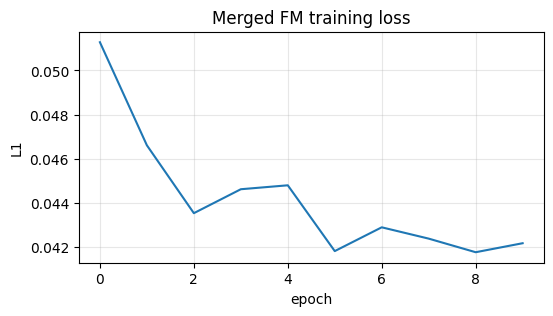

In [ ]:
# Train merged model on a mixture of (tetris, RGB rectangles)
merged_encoder.train()
merged_fm.train()

optimizer = torch.optim.AdamW(list(merged_encoder.parameters()) + list(merged_fm.parameters()), lr=MERGED_LR)

train_losses = []

for epoch in range(MERGED_EPOCHS):
    epoch_loss = 0.0

    for _ in tqdm(range(MERGED_STEPS_PER_EPOCH), desc=f"epoch {epoch+1}/{MERGED_EPOCHS}"):
        use_tetris = (random.random() < P_MIX_TETRIS)

        if use_tetris:
            base_gray, dino_emb = sample_tetris_batch(MERGED_BATCH_SIZE)  # gray in [-1,1]
            base_rgb = ((base_gray + 1.0) * 0.5).repeat(1, 3, 1, 1).clamp(0.0, 1.0)
        else:
            base_rgb = sample_color_batch(MERGED_BATCH_SIZE)
            dino_emb = torch.zeros((MERGED_BATCH_SIZE, 384), device=device)

        color_emb = merged_encoder(base_rgb)

        B = base_rgb.shape[0]
        ang_start = torch.rand(B, device=device) * 360.0
        ang_delta = torch.rand(B, device=device) * 360.0 - 180.0
        t = torch.rand(B, 1, device=device)

        ang_t = ang_start + (t.squeeze(1) * ang_delta)
        x_t = KG.rotate(base_rgb, ang_t)

        ang_next = ang_t + (MERGED_DT * ang_delta)
        x_next = KG.rotate(base_rgb, ang_next)

        target_v = (x_next - x_t) / MERGED_DT
        pred_v = merged_fm(x_t, t, dino_emb, color_emb, ang_delta.view(B, 1))

        loss = F.l1_loss(pred_v, target_v)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        epoch_loss += float(loss.item())

    avg = epoch_loss / MERGED_STEPS_PER_EPOCH
    train_losses.append(avg)
    print(f"Epoch {epoch+1}: L1={avg:.6f}")

plt.figure(figsize=(6, 3))
plt.plot(train_losses)
plt.title("Merged FM training loss")
plt.xlabel("epoch")
plt.ylabel("L1")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Evaluate merged FM on the Ganis-Kievit 3D task
merged_encoder.eval()
merged_fm.eval()

@torch.no_grad()
def apply_rotation_fm_merged(model, base_img_rgb01, dino_emb, color_emb, angle_deg, steps=10):
    dt = 1.0 / steps
    curr = base_img_rgb01.clone()
    B = curr.shape[0]
    target_ang = torch.full((B, 1), float(angle_deg), device=curr.device, dtype=curr.dtype)

    for i in range(steps):
        t = torch.full((B, 1), i / steps, device=curr.device, dtype=curr.dtype)
        v1 = model(curr, t, dino_emb, color_emb, target_ang)
        mid = curr + v1 * dt
        t2 = torch.full((B, 1), (i + 1) / steps, device=curr.device, dtype=curr.dtype)
        v2 = model(mid, t2, dino_emb, color_emb, target_ang)
        curr = curr + 0.5 * (v1 + v2) * dt
        curr = torch.nan_to_num(curr, nan=0.0, posinf=1.0, neginf=0.0)
        curr = curr.clamp(0.0, 1.0)

    return curr

@torch.no_grad()
def min_error_over_angles_merged(base_gray, base_rgb01, target_rgb01, angles: np.ndarray, steps: int = 10):
    dino_emb = get_dino_embedding(base_gray).squeeze(1)  # (B,384)
    color_emb = merged_encoder(base_rgb01)

    best_err = float("inf")
    best_angle = None

    for ang in angles:
        rot = apply_rotation_fm_merged(merged_fm, base_rgb01, dino_emb, color_emb, float(ang), steps=steps)
        err = torch.mean((rot - target_rgb01) ** 2).item()
        if err < best_err:
            best_err = err
            best_angle = float(ang)

    return best_err, best_angle

@torch.no_grad()
def evaluate_pair_merged(sample: Dict[str, Any], angles: np.ndarray, steps: int = 10) -> Dict[str, Any]:
    base_gray, target_gray = sample_to_tensors(sample, device=device)
    base_rgb, target_rgb = sample_to_rgb01(sample, device=device)

    err_orig, ang_orig = min_error_over_angles_merged(base_gray, base_rgb, target_rgb, angles, steps)

    base_gray_flip = torch.flip(base_gray, dims=[3])
    base_rgb_flip = torch.flip(base_rgb, dims=[3])
    err_flip, ang_flip = min_error_over_angles_merged(base_gray_flip, base_rgb_flip, target_rgb, angles, steps)

    label_same = (sample.get("label") == "same")
    pred_same = err_orig <= err_flip
    score = err_flip - err_orig

    return {
        "err_orig": err_orig,
        "err_flip": err_flip,
        "best_angle": ang_orig,
        "best_angle_flip": ang_flip,
        "label_same": label_same,
        "pred_same": pred_same,
        "score": score,
        "name": sample.get("name"),
        "angle": sample.get("angle"),
    }

results_merged = []
raw_iter = test_raw[:MAX_TEST] if MAX_TEST is not None else test_raw

for sample in tqdm(raw_iter, total=len(raw_iter)):
    results_merged.append(evaluate_pair_merged(sample, ANGLES, steps=FM_STEPS))

labels_m = np.array([1 if r["label_same"] else 0 for r in results_merged], dtype=np.int32)
preds_m = np.array([1 if r["pred_same"] else 0 for r in results_merged], dtype=np.int32)
scores_m = np.array([r["score"] for r in results_merged], dtype=np.float32)

acc_m = accuracy_score(labels_m, preds_m)
auc_m = roc_auc_score(labels_m, scores_m)

print("Merged FM rotation search results")
print("  Accuracy (mirror-vs-rotation rule):", f"{acc_m:.4f}")
print("  AUC (score = err_flip - err_orig):", f"{auc_m:.4f}")

100%|██████████| 78/78 [16:23<00:00, 12.60s/it]

Merged FM rotation search results
  Accuracy (mirror-vs-rotation rule): 0.6282
  AUC (score = err_flip - err_orig): 0.6857


In [ ]:
# Summary table
rows = []

# tetris
labels_t = np.array([1 if r["label_same"] else 0 for r in results], dtype=np.int32)
score_t = np.array([r["score"] for r in results], dtype=np.float32)
auc_t = roc_auc_score(labels_t, score_t)
acc_t = accuracy_score(labels_t, (score_t > 0).astype(np.int32))  # not the same as the err_orig<=err_flip rule, but comparable thresholded score
rows.append(("tetris_fm", float(acc), float(auc_t)))

# color
labels_c = np.array([1 if r["label_same"] else 0 for r in results_color], dtype=np.int32)
score_c = np.array([r["score"] for r in results_color], dtype=np.float32)
auc_c = roc_auc_score(labels_c, score_c)
acc_c = accuracy_score(labels_c, (score_c > 0).astype(np.int32))
rows.append(("color_fm", float(acc_color), float(auc_c)))

# late fusion
rows.append(("late_fusion", float(acc_late), float(auc_late)))

# merged
if 'results_merged' in globals():
    labels_mm = np.array([1 if r["label_same"] else 0 for r in results_merged], dtype=np.int32)
    score_mm = np.array([r["score"] for r in results_merged], dtype=np.float32)
    auc_mm = roc_auc_score(labels_mm, score_mm)
    rows.append(("merged_fm", float(acc_m), float(auc_mm)))

print("\nModel\t\tAccuracy\tAUC")
for name, a, u in rows:
    print(f"{name:12s}\t{a:.4f}\t\t{u:.4f}")


NameError: name 'results' is not defined